# ASL Alphabet — Raw XYZ vs Feature Engineering: Analisi Clustering

L'obiettivo è capire **quando e quanto** la feature engineering (distanze, angoli, ecc.) differenzia le lettere rispetto alle sole coordinate grezze (x, y, z) dei 21 landmark della mano.

**Struttura del CSV:**
- Colonna 0: filepath
- Colonna 1: label (lettera)
- Colonna 2: hand (Left/Right)
- Colonne 3–5: landmark 0 (wrist) → solitamente 0,0,0
- Colonne 6–68: landmark 1–21 × (x,y,z) = 63 valori raw
- Colonne 69+: feature engineered (distanze palm, angoli dita, ecc.)

**Focus speciale:**
- Cluster generale su tutte le lettere
- Zoom su **M, N, T** (simili per forma)
- Zoom su **A, S** (simili per forma)

In [1]:
# ── Installazioni (esegui solo la prima volta) ──────────────────────────────
# !pip install pandas numpy scikit-learn matplotlib seaborn umap-learn plotly nbformat --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from util.paths import DATA_DIR

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    confusion_matrix, classification_report
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Stile
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = sns.color_palette('tab20', 29)   # 26 lettere + spazio + delete + nothing

print('✓ Librerie caricate')

✓ Librerie caricate


---
## 1. Caricamento e parsing del dataset

In [3]:
# ── Adatta questo path al tuo file CSV ─────────────────────────────────────
CSV_PATH = DATA_DIR / "asl_features_engineered.csv"
# ───────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv(CSV_PATH, header=0)  # header=0 → prima riga = nomi colonne, saltata dai dati
print(f'Shape: {df_raw.shape}')
print(f'Colonne ({len(df_raw.columns)}): {list(df_raw.columns[:6])} ...')
df_raw.head(3)

Shape: (154924, 98)
Colonne (98): ['filepath', 'label', 'handedness', 'lm_0', 'lm_1', 'lm_2'] ...


,filepath,label,handedness,lm_0,lm_1,lm_2,lm_3,lm_4,lm_5,lm_6,...,thumb_vector_x,thumb_vector_y,index_vector_x,index_vector_y,middle_vector_x,middle_vector_y,ring_vector_x,ring_vector_y,pinky_vector_x,pinky_vector_y
0,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.0,0.0,0.0,0.427800,-0.183697,-0.123250,0.696755,...,0.919328,-1.274315,0.467928,-0.695018,0.307523,-0.538502,0.133816,-0.352078,-0.051700,-0.400983
1,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.0,0.0,0.0,0.460919,-0.164935,-0.085907,0.742879,...,1.039106,-1.303279,0.506525,-0.777851,0.310194,-0.660715,0.124279,-0.430862,-0.068093,-0.466462
2,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.0,0.0,0.0,0.387421,-0.021154,-0.081727,0.717863,...,0.964733,-1.163269,0.545202,-0.570772,0.355300,-0.480491,0.174188,-0.458983,0.038772,-0.561456


In [4]:
# ── Separazione colonne ────────────────────────────────────────────────────
# Struttura attesa (indici posizionali, funziona con qualsiasi nome header):
#   col 0 = filepath | col 1 = label | col 2 = hand
#   col 3..65 = 21 landmark x xyz (63 raw features)
#   col 66..N = feature engineered
labels = df_raw.iloc[:, 1].astype(str).str.upper()
hand   = df_raw.iloc[:, 2]

raw_cols = list(range(3, 66))               # 63 features
eng_cols = list(range(66, df_raw.shape[1])) # tutto il resto = engineered

X_raw = df_raw.iloc[:, raw_cols].astype(float).values
X_eng = df_raw.iloc[:, eng_cols].astype(float).values
X_all = np.hstack([X_raw, X_eng])

print(f'Righe dati     : {len(df_raw)}')
print(f'Landmark raw   : {X_raw.shape[1]} features')
print(f'Engineered     : {X_eng.shape[1]} features')
print(f'Totale         : {X_all.shape[1]} features')
print(f'Classi uniche  : {sorted(labels.unique())}')

Righe dati     : 154924
Landmark raw   : 63 features
Engineered     : 32 features
Totale         : 95 features
Classi uniche  : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [5]:
# ── Encoding label ─────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y  = le.fit_transform(labels)
label_names = le.classes_
n_classes   = len(label_names)

# Palette per classe
palette_dict = {name: PALETTE[i % 20] for i, name in enumerate(label_names)}

print(f'Numero classi: {n_classes}')
print('Distribuzione campioni per classe:')
print(labels.value_counts().sort_index().to_string())

Numero classi: 26
Distribuzione campioni per classe:
label
A    5894
B    6260
C    5587
D    6403
E    5700
F    7711
G    6733
H    6358
I    6229
J    5968
K    6970
L    6967
M    5050
N    4177
O    5904
P    5220
Q    5477
R    6550
S    6157
T    2308
U    6317
V    6403
W    6472
X    5874
Y    6323
Z    5912


In [6]:
# ── Campionamento bilanciato per velocità (max 300 per classe) ─────────────
SAMPLE_PER_CLASS = 300
rng = np.random.default_rng(42)

idx_list = []
for cls in range(n_classes):
    idx_cls = np.where(y == cls)[0]
    chosen  = rng.choice(idx_cls, size=min(SAMPLE_PER_CLASS, len(idx_cls)), replace=False)
    idx_list.append(chosen)

idx_sample = np.concatenate(idx_list)

X_raw_s = X_raw[idx_sample]
X_eng_s = X_eng[idx_sample]
X_all_s = X_all[idx_sample]
y_s     = y[idx_sample]
lab_s   = labels.iloc[idx_sample].values

print(f'Campioni totali dopo sampling: {len(idx_sample)}')

Campioni totali dopo sampling: 7800


---
## 2. Preprocessing: standardizzazione + PCA

In [7]:
def preprocess_and_pca(X, n_components=50, label=''):
    """Standardizza e riduce con PCA."""
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)
    pca    = PCA(n_components=min(n_components, X_sc.shape[1]), random_state=42)
    X_pca  = pca.fit_transform(X_sc)
    var_exp = pca.explained_variance_ratio_.cumsum()
    print(f'[{label}] Varianza spiegata con {n_components} PC: {var_exp[-1]:.1%}')
    return X_sc, X_pca, pca, scaler

_, X_raw_pca, pca_raw, sc_raw = preprocess_and_pca(X_raw_s, 50, 'RAW')
_, X_eng_pca, pca_eng, sc_eng = preprocess_and_pca(X_eng_s, 50, 'ENG')
_, X_all_pca, pca_all, sc_all = preprocess_and_pca(X_all_s, 50, 'ALL')

[RAW] Varianza spiegata con 50 PC: 100.0%
[ENG] Varianza spiegata con 50 PC: 100.0%
[ALL] Varianza spiegata con 50 PC: 100.0%


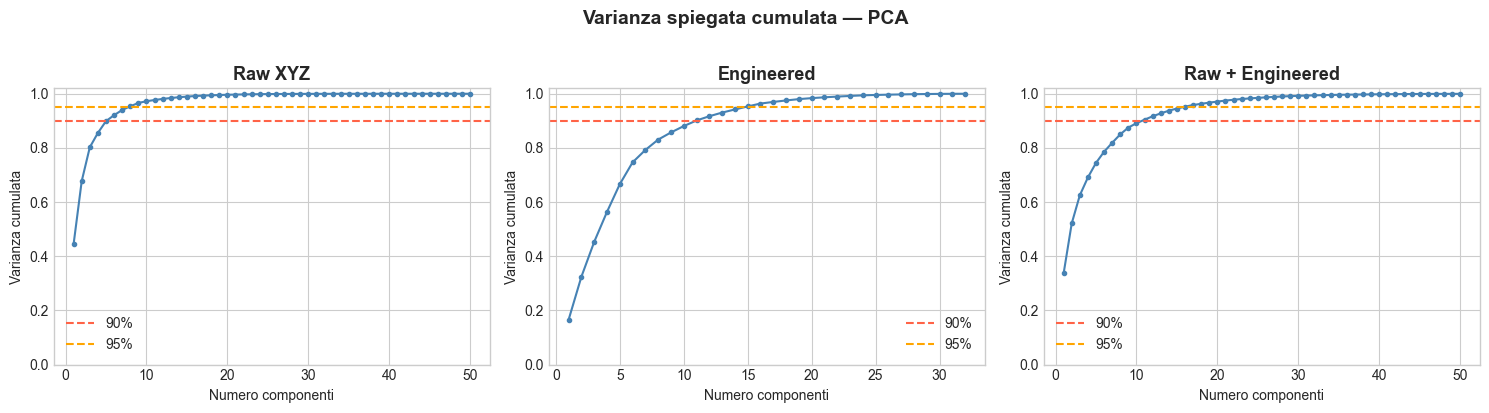

Salvato: 01_pca_variance.png


In [8]:
# ── Varianza spiegata cumulata ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pca, title in zip(axes,
                           [pca_raw, pca_eng, pca_all],
                           ['Raw XYZ', 'Engineered', 'Raw + Engineered']):
    cumvar = pca.explained_variance_ratio_.cumsum()
    ax.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3, color='steelblue')
    ax.axhline(0.9, color='tomato', linestyle='--', label='90%')
    ax.axhline(0.95, color='orange', linestyle='--', label='95%')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Numero componenti')
    ax.set_ylabel('Varianza cumulata')
    ax.legend()
    ax.set_ylim(0, 1.02)

plt.suptitle('Varianza spiegata cumulata — PCA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()
print('Salvato: 01_pca_variance.png')

---
## 3. t-SNE: visualizzazione 2D — confronto Raw vs Engineered

In [9]:
# t-SNE sui primi 30 PC (bilanciamento velocità/qualità)
print('Calcolo t-SNE (potrebbe richiedere qualche minuto)...')

import sklearn
# n_iter rinominato max_iter dalla versione 1.5 di scikit-learn
_tsne_iter_kwarg = 'max_iter' if tuple(int(x) for x in sklearn.__version__.split('.')[:2]) >= (1, 5) else 'n_iter'

tsne  = TSNE(n_components=2, perplexity=40, random_state=42, **{_tsne_iter_kwarg: 1000})
emb_raw = tsne.fit_transform(X_raw_pca[:, :30])
print('  ✓ t-SNE su Raw')

tsne2 = TSNE(n_components=2, perplexity=40, random_state=42, **{_tsne_iter_kwarg: 1000})
emb_all = tsne2.fit_transform(X_all_pca[:, :30])
print('  ✓ t-SNE su Raw + Engineered')

Calcolo t-SNE (potrebbe richiedere qualche minuto)...
  ✓ t-SNE su Raw
  ✓ t-SNE su Raw + Engineered


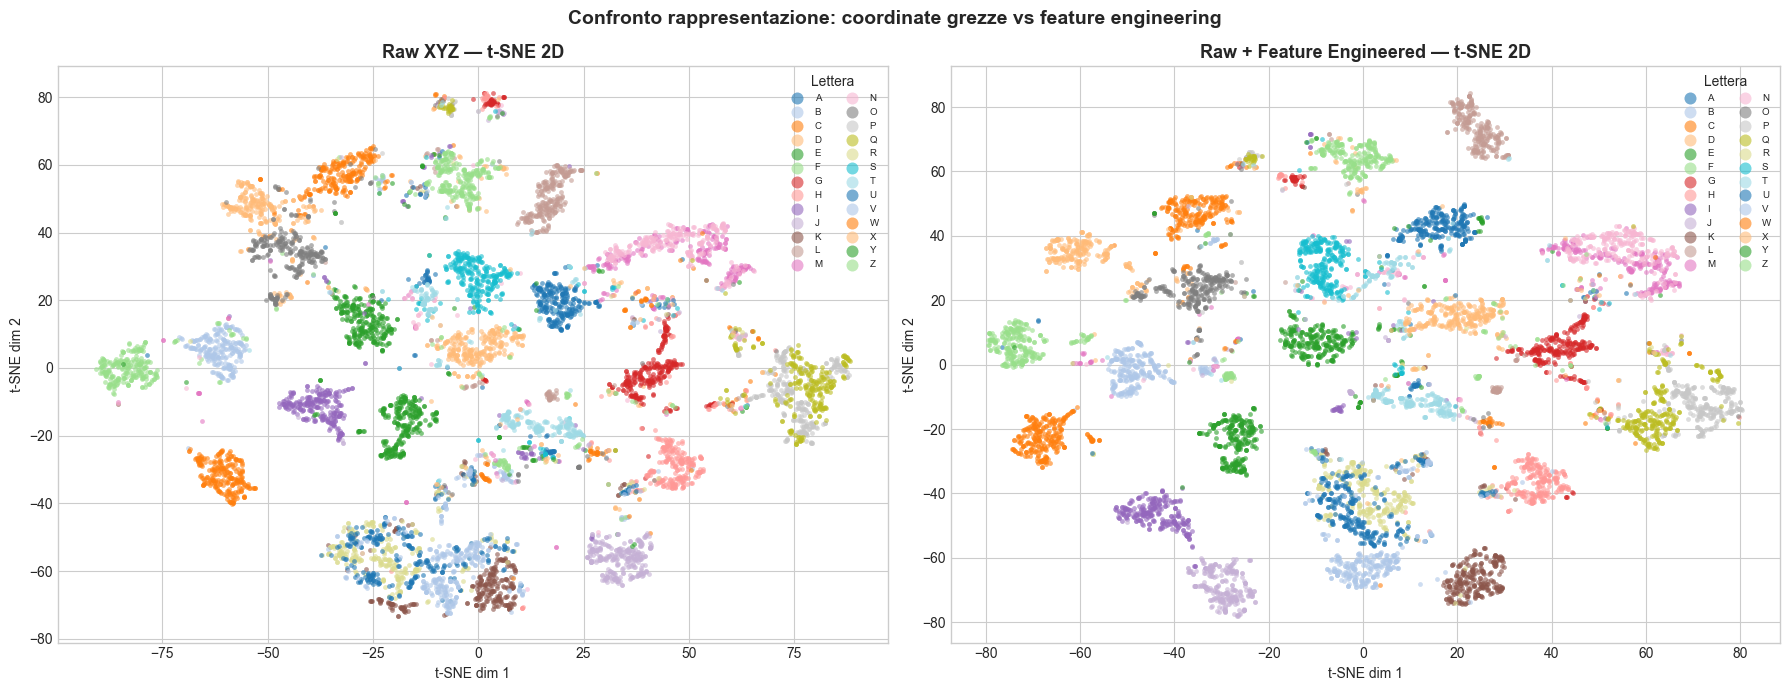

Salvato: 02_tsne_global.png


In [10]:
def plot_tsne(emb, labels_arr, palette, title, ax, show_legend=True):
    unique_labels = sorted(set(labels_arr))
    for lbl in unique_labels:
        mask = labels_arr == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[palette[lbl]], label=lbl,
                   s=12, alpha=0.6, linewidths=0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    if show_legend:
        ax.legend(markerscale=2.5, fontsize=7,
                  loc='upper right', ncol=2,
                  framealpha=0.8, title='Lettera')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_tsne(emb_raw, lab_s, palette_dict, 'Raw XYZ — t-SNE 2D', axes[0])
plot_tsne(emb_all, lab_s, palette_dict, 'Raw + Feature Engineered — t-SNE 2D', axes[1])

plt.suptitle('Confronto rappresentazione: coordinate grezze vs feature engineering',
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()
print('Salvato: 02_tsne_global.png')

---
## 4. Clustering KMeans: Silhouette Score — Raw vs Engineered

In [11]:
# KMeans con k = numero di classi reali
k = n_classes

results = {}
for name, X_pca in [('Raw XYZ', X_raw_pca), ('Engineered', X_eng_pca), ('Raw + Eng', X_all_pca)]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=500)
    pred = km.fit_predict(X_pca)
    sil  = silhouette_score(X_pca, pred, sample_size=2000, random_state=42)
    ari  = adjusted_rand_score(y_s, pred)
    results[name] = {'silhouette': sil, 'ARI': ari, 'pred': pred}
    print(f'[{name}]  Silhouette={sil:.4f}   ARI={ari:.4f}')

[Raw XYZ]  Silhouette=0.2389   ARI=0.3145
[Engineered]  Silhouette=0.3717   ARI=0.5375
[Raw + Eng]  Silhouette=0.2831   ARI=0.5050


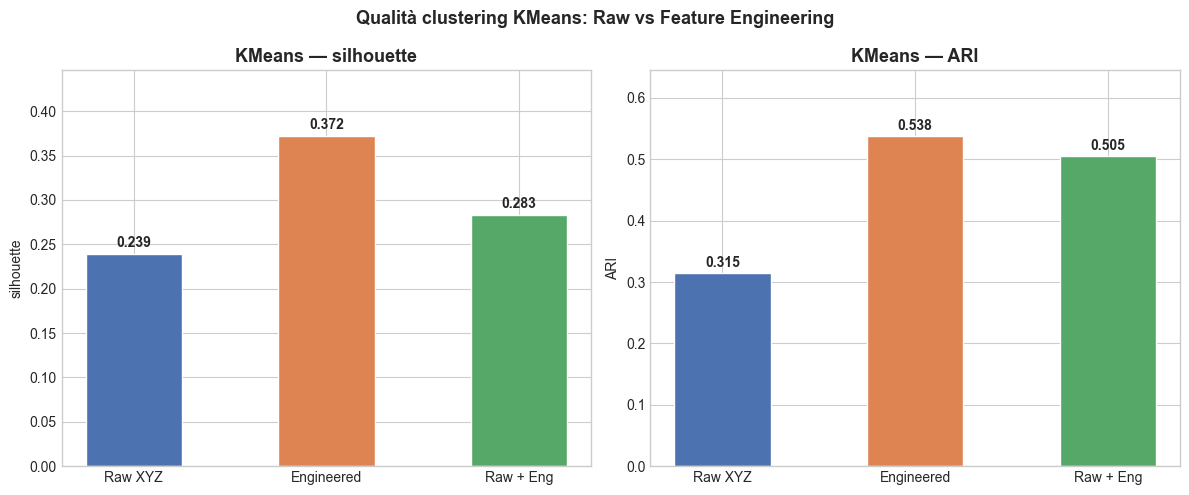

Salvato: 03_kmeans_metrics.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['silhouette', 'ARI']):
    names  = list(results.keys())
    values = [results[n][metric] for n in names]
    bars   = ax.bar(names, values,
                    color=['#4C72B0', '#DD8452', '#55A868'],
                    width=0.5, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'KMeans — {metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(values) * 1.2)

plt.suptitle('Qualità clustering KMeans: Raw vs Feature Engineering',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()
print('Salvato: 03_kmeans_metrics.png')

---
## 5. LDA: separabilità massima tra classi

In [13]:
# LDA riduce alle (n_classi-1) componenti discriminanti
def fit_lda(X, y, label):
    sc  = StandardScaler()
    Xsc = sc.fit_transform(X)
    lda = LDA(n_components=2)
    emb = lda.fit_transform(Xsc, y)
    return emb

lda_raw = fit_lda(X_raw_s, y_s, 'Raw')
lda_all = fit_lda(X_all_s, y_s, 'All')
print('✓ LDA calcolato')

✓ LDA calcolato


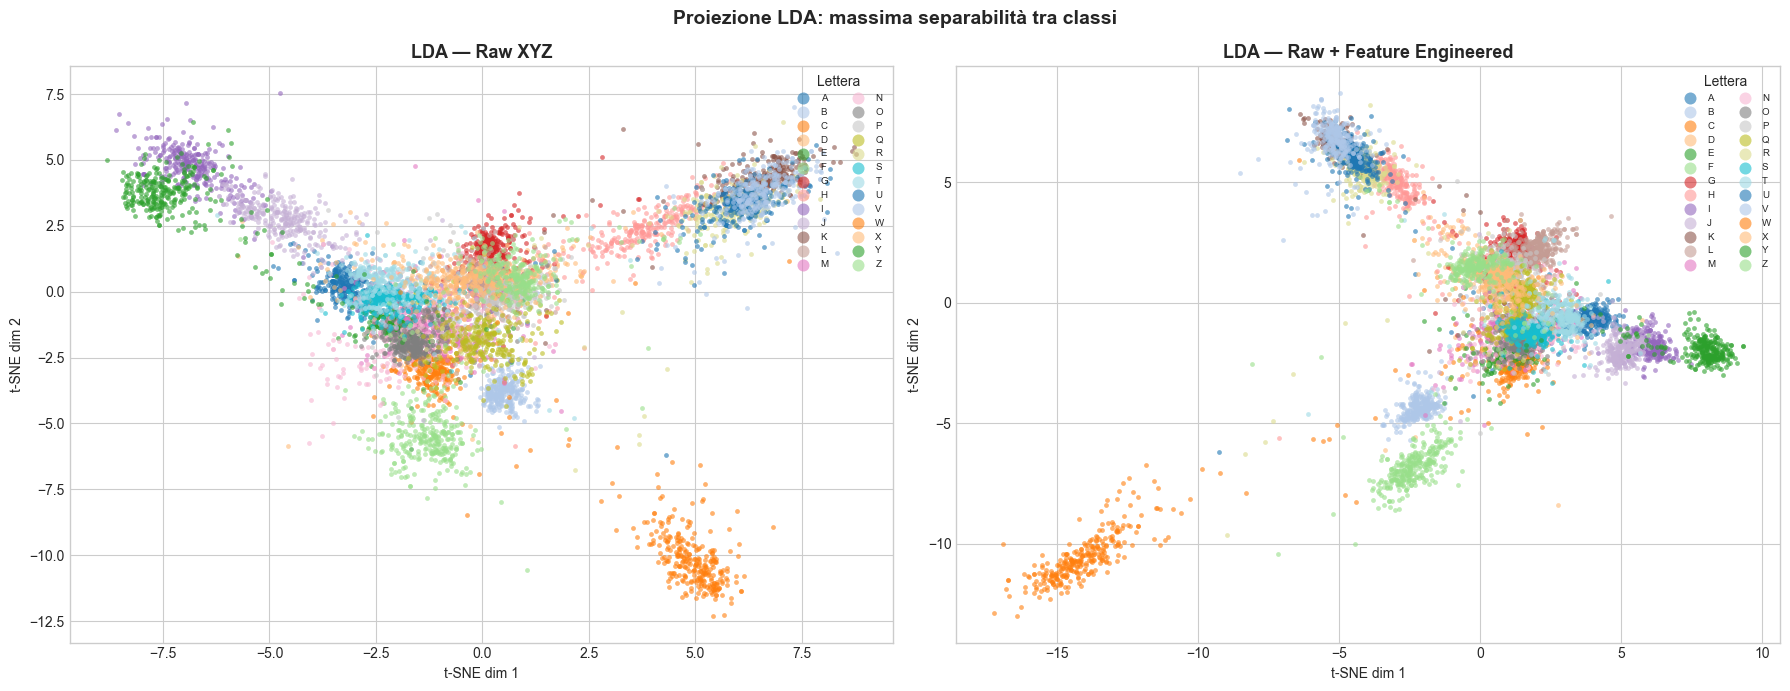

Salvato: 04_lda_global.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_tsne(lda_raw, lab_s, palette_dict, 'LDA — Raw XYZ', axes[0])
plot_tsne(lda_all, lab_s, palette_dict, 'LDA — Raw + Feature Engineered', axes[1])

plt.suptitle('Proiezione LDA: massima separabilità tra classi',
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()
print('Salvato: 04_lda_global.png')

---
## 6. FOCUS: M, N, T — lettere simili nella forma della mano

In [15]:
FOCUS_MNT = ['M', 'N', 'T']

mask_mnt = np.isin(lab_s, FOCUS_MNT)
lab_mnt  = lab_s[mask_mnt]
y_mnt    = y_s[mask_mnt]

Xr_mnt   = X_raw_s[mask_mnt]
Xa_mnt   = X_all_s[mask_mnt]

print(f'Campioni per M/N/T: {mask_mnt.sum()}')
for l in FOCUS_MNT:
    print(f'  {l}: {(lab_mnt == l).sum()}')

Campioni per M/N/T: 900
  M: 300
  N: 300
  T: 300


In [16]:
# t-SNE su sottoinsieme M,N,T
palette_mnt = {'M': '#E74C3C', 'N': '#3498DB', 'T': '#2ECC71'}

def tsne_focus(X, label):
    sc  = StandardScaler()
    Xsc = sc.fit_transform(X)
    pca = PCA(n_components=min(30, Xsc.shape[1]), random_state=42)
    Xp  = pca.fit_transform(Xsc)
    t   = TSNE(n_components=2, perplexity=30, random_state=42, **{_tsne_iter_kwarg: 1000})
    emb = t.fit_transform(Xp)
    print(f'  ✓ t-SNE {label}')
    return emb

print('t-SNE M/N/T...')
emb_mnt_raw = tsne_focus(Xr_mnt, 'M/N/T Raw')
emb_mnt_all = tsne_focus(Xa_mnt, 'M/N/T All')

t-SNE M/N/T...
  ✓ t-SNE M/N/T Raw
  ✓ t-SNE M/N/T All


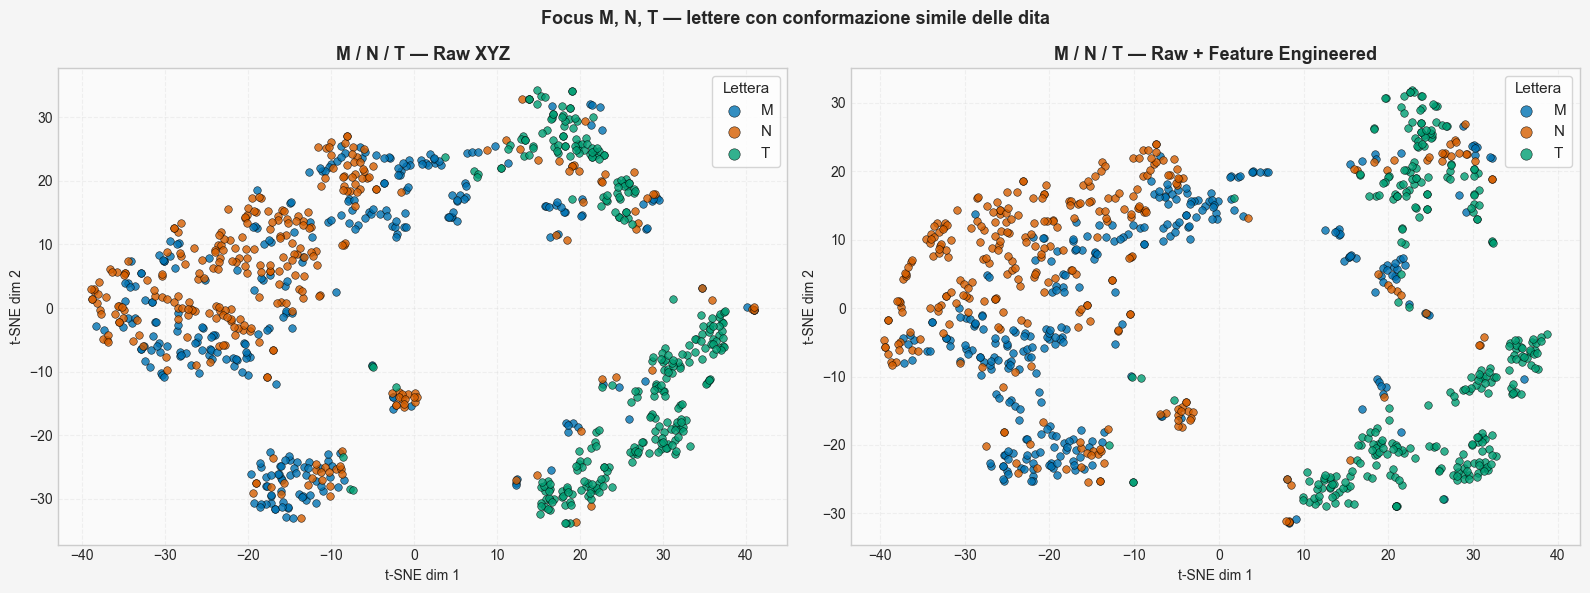

Salvato: 05_tsne_MNT.png


In [35]:
import matplotlib.pyplot as plt


palette_mnt = {
    'M': '#0072B2',  # blu
    'N': '#D55E00',  # arancione/vermiglio
    'T': '#009E73'   # verde
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sfondo figura
fig.patch.set_facecolor('#F5F5F5')

for ax, emb, title in zip(
        axes,
        [emb_mnt_raw, emb_mnt_all],
        ['Raw XYZ', 'Raw + Feature Engineered']):

    # Sfondo asse
    ax.set_facecolor('#FAFAFA')

    # Griglia leggera
    ax.grid(True, linestyle='--', alpha=0.25)

    for lbl in FOCUS_MNT:
        mask = (lab_mnt == lbl)

        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            c=palette_mnt[lbl],
            label=lbl,
            s=30,
            alpha=0.8,
            edgecolors='black',
            linewidths=0.4
        )

    ax.set_title(
        f'M / N / T — {title}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')

    ax.legend(
        title='Lettera',
        fontsize=11,
        title_fontsize=11,
        markerscale=1.5,
        frameon=True
    )

plt.suptitle(
    'Focus M, N, T — lettere con conformazione simile delle dita',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# Salvataggio con sfondo corretto
plt.savefig(
    '05_tsne_MNT.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

print('Salvato: 05_tsne_MNT.png')

In [18]:
# ── KMeans su M, N, T (k=3) ───────────────────────────────────────────────
print('=== Clustering M/N/T (k=3) ===')
for name, X in [('Raw XYZ', Xr_mnt), ('Raw + Eng', Xa_mnt)]:
    sc  = StandardScaler()
    Xsc = sc.fit_transform(X)
    pca = PCA(n_components=20, random_state=42)
    Xp  = pca.fit_transform(Xsc)
    km  = KMeans(n_clusters=3, random_state=42, n_init=15)
    pred = km.fit_predict(Xp)
    sil  = silhouette_score(Xp, pred)
    ari  = adjusted_rand_score(y_mnt, pred)
    print(f'  [{name}] Silhouette={sil:.4f}  ARI={ari:.4f}')

=== Clustering M/N/T (k=3) ===
  [Raw XYZ] Silhouette=0.4083  ARI=0.3394
  [Raw + Eng] Silhouette=0.2722  ARI=0.3464


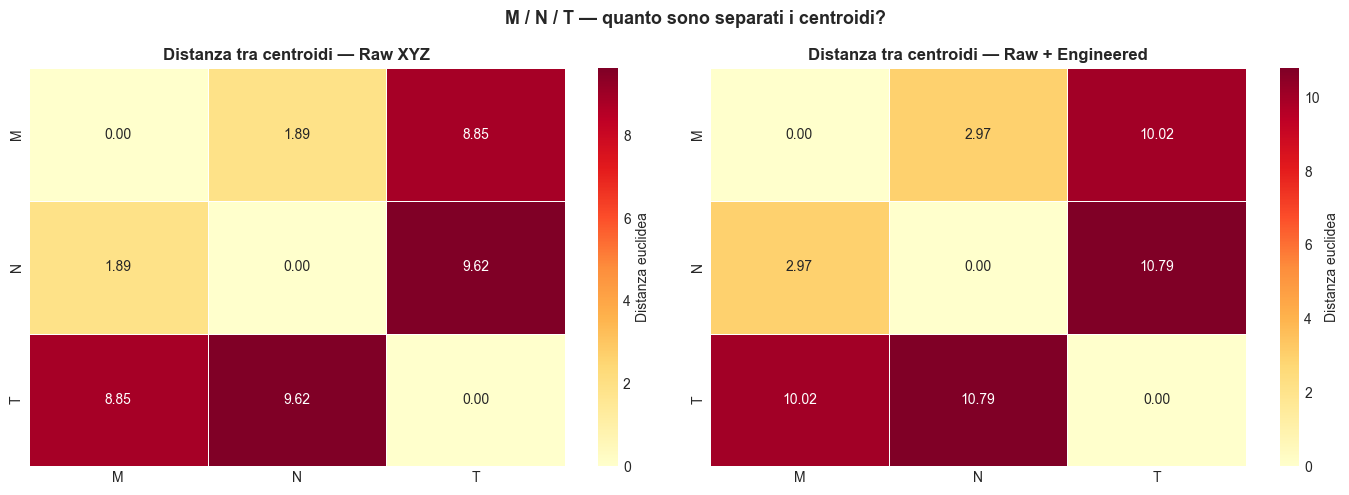

Salvato: 06_centroid_dist_MNT.png


In [19]:
# ── Heatmap distanze medie tra cluster M/N/T ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X, title in zip(axes,
                         [Xr_mnt, Xa_mnt],
                         ['Raw XYZ', 'Raw + Engineered']):
    sc  = StandardScaler()
    Xsc = sc.fit_transform(X)
    # Centroidi per lettera
    centroids = np.array([Xsc[lab_mnt == l].mean(axis=0) for l in FOCUS_MNT])
    # Distanza euclidea normalizzata tra coppie di centroidi
    n = len(FOCUS_MNT)
    dist_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist_mat[i, j] = np.linalg.norm(centroids[i] - centroids[j])
    sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=FOCUS_MNT, yticklabels=FOCUS_MNT, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Distanza euclidea'})
    ax.set_title(f'Distanza tra centroidi — {title}', fontweight='bold')

plt.suptitle('M / N / T — quanto sono separati i centroidi?',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()
print('Salvato: 06_centroid_dist_MNT.png')

---
## 7. FOCUS: A, S, E — lettere con pugno chiuso (simili per forma)

In [20]:
FOCUS_AS = ['A', 'S', 'E']

mask_as = np.isin(lab_s, FOCUS_AS)
lab_as  = lab_s[mask_as]
y_as    = y_s[mask_as]
Xr_as   = X_raw_s[mask_as]
Xa_as   = X_all_s[mask_as]

print(f'Campioni A/S/E: {mask_as.sum()}')
for l in FOCUS_AS:
    print(f'  {l}: {(lab_as == l).sum()}')

Campioni A/S/E: 900
  A: 300
  S: 300
  E: 300


In [21]:
print('t-SNE A/S/E...')
emb_as_raw = tsne_focus(Xr_as, 'A/S/E Raw')
emb_as_all = tsne_focus(Xa_as, 'A/S/E All')

t-SNE A/S/E...
  ✓ t-SNE A/S/E Raw
  ✓ t-SNE A/S/E All


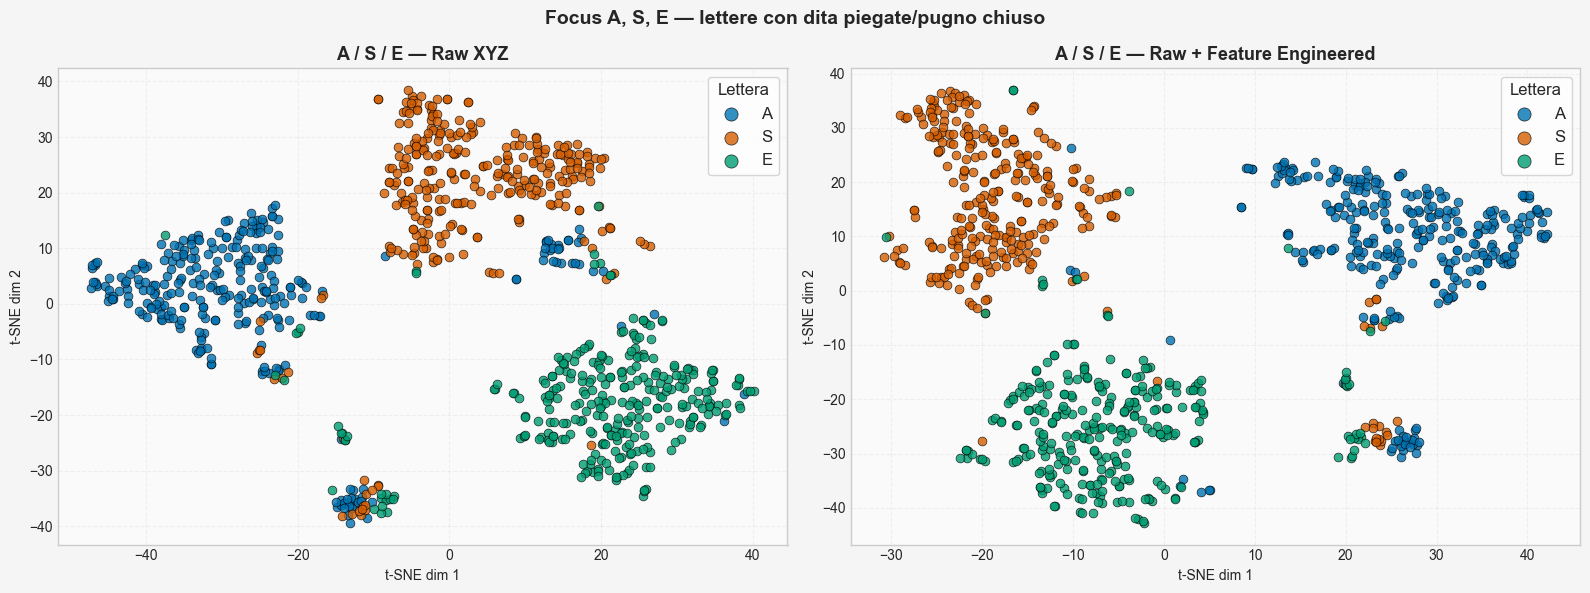

Salvato: 07_tsne_ASE.png


In [33]:
import matplotlib.pyplot as plt

# Palette ad alto contrasto (Okabe-Ito)
palette_as = {
    'A': '#0072B2',  # blu
    'S': '#D55E00',  # arancione/vermiglio
    'E': '#009E73'   # verde
}

# Creazione figura
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

# Sfondo figura
fig.patch.set_facecolor('#F5F5F5')

for ax, emb, title in zip(
        axes,
        [emb_as_raw, emb_as_all],
        ['Raw XYZ', 'Raw + Feature Engineered']):

    # Sfondo del singolo grafico
    ax.set_facecolor('#FAFAFA')

    # Griglia
    ax.grid(True, linestyle='--', alpha=0.25)

    # Scatter per ciascuna lettera
    for lbl in FOCUS_AS:
        mask = (lab_as == lbl)

        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            color=palette_as[lbl],
            label=lbl,
            s=40,
            alpha=0.8,
            edgecolors='black',
            linewidths=0.5
        )

    ax.set_title(
        f'A / S / E — {title}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')

    ax.legend(
        title='Lettera',
        fontsize=12,
        title_fontsize=12,
        markerscale=1.5,
        frameon=True
    )

plt.suptitle(
    'Focus A, S, E — lettere con dita piegate/pugno chiuso',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

# Salvataggio mantenendo lo sfondo
plt.savefig(
    '07_tsne_ASE.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

print('Salvato: 07_tsne_ASE.png')

In [23]:
# ── KMeans A/S/E (k=3) ────────────────────────────────────────────────────
print('=== Clustering A/S/E (k=3) ===')
for name, X in [('Raw XYZ', Xr_as), ('Raw + Eng', Xa_as)]:
    sc  = StandardScaler()
    Xsc = sc.fit_transform(X)
    pca = PCA(n_components=15, random_state=42)
    Xp  = pca.fit_transform(Xsc)
    km  = KMeans(n_clusters=3, random_state=42, n_init=15)
    pred = km.fit_predict(Xp)
    sil  = silhouette_score(Xp, pred)
    ari  = adjusted_rand_score(y_as, pred)
    print(f'  [{name}] Silhouette={sil:.4f}  ARI={ari:.4f}')

=== Clustering A/S/E (k=3) ===
  [Raw XYZ] Silhouette=0.7615  ARI=0.0001
  [Raw + Eng] Silhouette=0.2607  ARI=0.4030


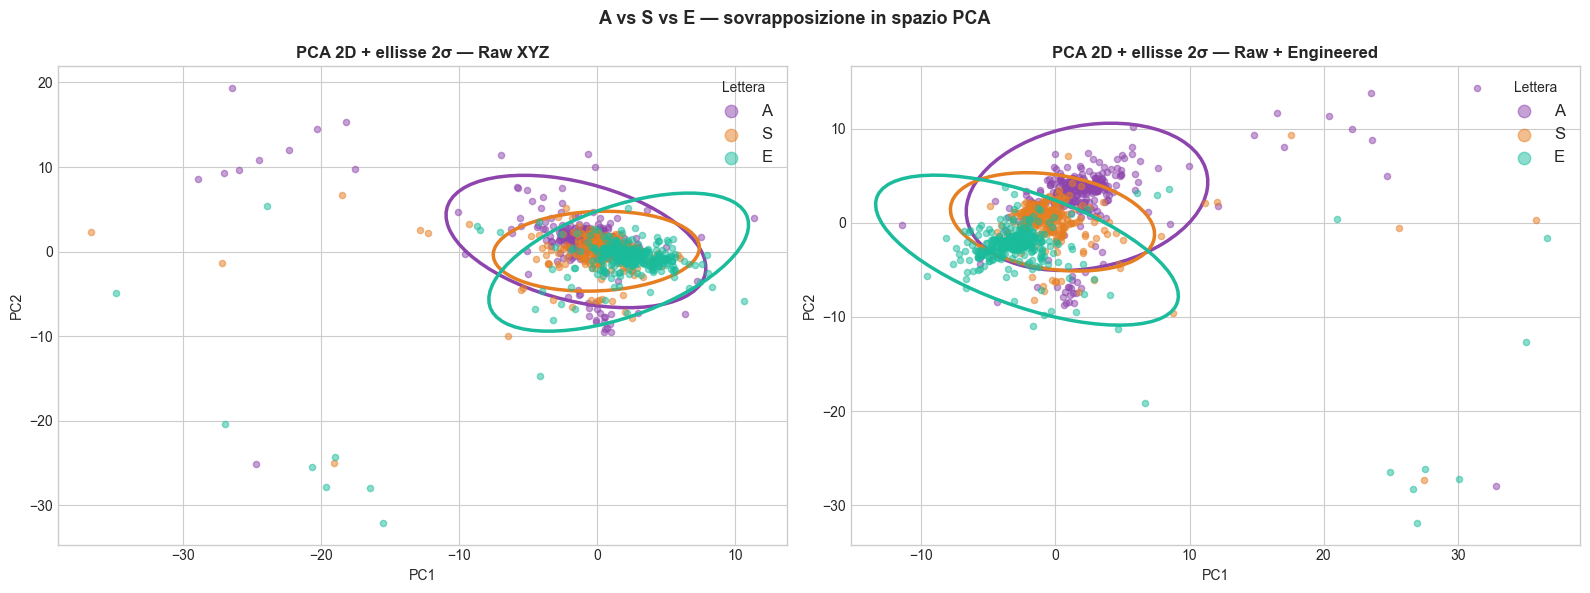

Salvato: 08_pca_ellipse_ASE.png


In [24]:
# ── PCA 2D con ellissi di confidenza per A/S ──────────────────────────────
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx*2, height=ry*2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf  = transforms.Affine2D() \
                         .rotate_deg(45) \
                         .scale(scale_x, scale_y) \
                         .translate(np.mean(x), np.mean(y))
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X, title in zip(axes, [Xr_as, Xa_as], ['Raw XYZ', 'Raw + Engineered']):
    sc  = StandardScaler()
    Xp  = PCA(n_components=2, random_state=42).fit_transform(sc.fit_transform(X))
    for lbl, col in palette_as.items():
        mask = lab_as == lbl
        ax.scatter(Xp[mask, 0], Xp[mask, 1],
                   c=col, label=lbl, s=20, alpha=0.5)
        confidence_ellipse(Xp[mask, 0], Xp[mask, 1], ax, n_std=2,
                           facecolor='none', edgecolor=col, linewidth=2.5)
    ax.set_title(f'PCA 2D + ellisse 2\u03c3 \u2014 {title}', fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(markerscale=2, fontsize=12, title='Lettera')

plt.suptitle('A vs S vs E \u2014 sovrapposizione in spazio PCA',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()
print('Salvato: 08_pca_ellipse_ASE.png')

---
## 9. Riepilogo comparativo: boxplot Silhouette per tutti i subset

In [26]:
def silhouette_bootstrap(X, y_true, k, n_iter=15, label=''):
    """Bootstrap Silhouette Score per stimare la varianza."""
    sc  = StandardScaler()
    Xsc = sc.fit_transform(X)
    pca = PCA(n_components=min(30, Xsc.shape[1]), random_state=42)
    Xp  = pca.fit_transform(Xsc)
    scores = []
    rng2 = np.random.default_rng(0)
    for _ in range(n_iter):
        boot = rng2.choice(len(Xp), size=min(500, len(Xp)), replace=False)
        km   = KMeans(n_clusters=k, random_state=_, n_init=5, max_iter=200)
        pred = km.fit_predict(Xp[boot])
        sil  = silhouette_score(Xp[boot], pred)
        scores.append(sil)
    print(f'  [{label}] Silhouette media={np.mean(scores):.4f} ± {np.std(scores):.4f}')
    return scores

print('Bootstrap Silhouette — questa cella richiede ~1-2 min...')
sil_data = {
    'Global\nRaw':      silhouette_bootstrap(X_raw_s, y_s, n_classes, label='Global Raw'),
    'Global\nRaw+Eng':  silhouette_bootstrap(X_all_s, y_s, n_classes, label='Global All'),
    'M/N/T\nRaw':       silhouette_bootstrap(Xr_mnt, y_mnt, 3, label='MNT Raw'),
    'M/N/T\nRaw+Eng':   silhouette_bootstrap(Xa_mnt, y_mnt, 3, label='MNT All'),
    'A/S/E\nRaw':       silhouette_bootstrap(Xr_as, y_as, 3, label='ASE Raw'),
    'A/S/E\nRaw+Eng':   silhouette_bootstrap(Xa_as, y_as, 3, label='ASE All'),
}

Bootstrap Silhouette — questa cella richiede ~1-2 min...
  [Global Raw] Silhouette media=0.2334 ± 0.0170
  [Global All] Silhouette media=0.3102 ± 0.0203
  [MNT Raw] Silhouette media=0.3661 ± 0.0478
  [MNT All] Silhouette media=0.2816 ± 0.0281
  [ASE Raw] Silhouette media=0.5367 ± 0.2470
  [ASE All] Silhouette media=0.3816 ± 0.1917


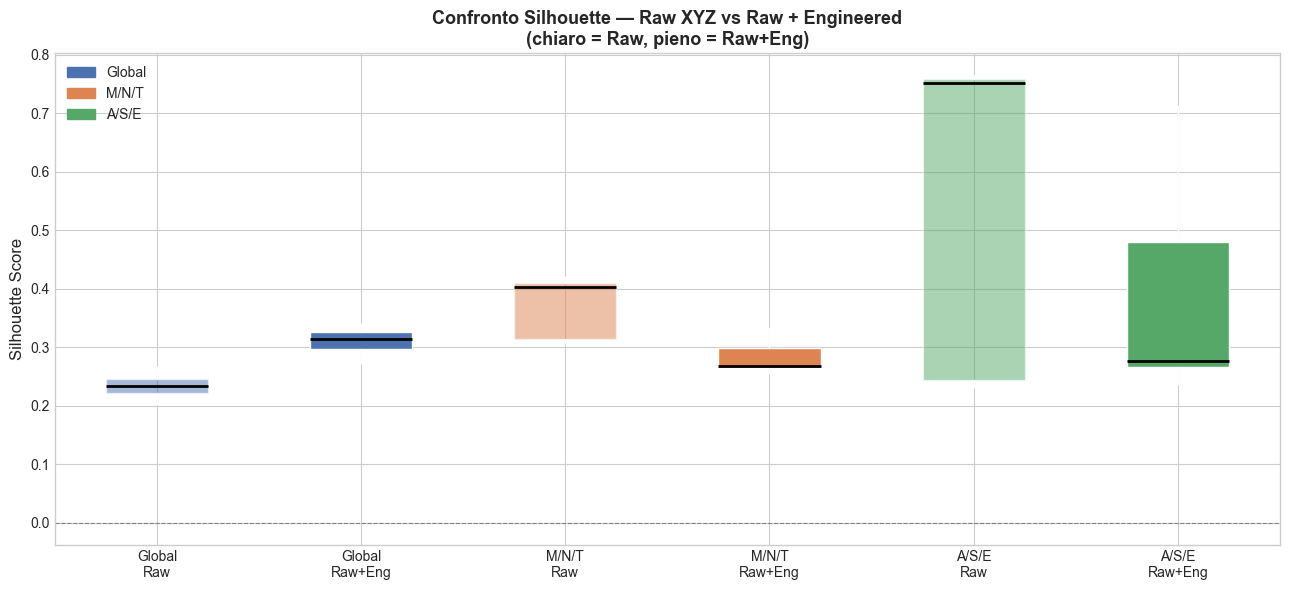

Salvato: 11_silhouette_summary.png


In [27]:
fig, ax = plt.subplots(figsize=(13, 6))
positions = list(range(len(sil_data)))
data_vals = list(sil_data.values())
labels_bp = list(sil_data.keys())

colors = ['#4C72B0', '#4C72B0',   # Global
          '#DD8452', '#DD8452',   # MNT
          '#55A868', '#55A868']   # AS
alphas = [0.5, 1.0, 0.5, 1.0, 0.5, 1.0]

bp = ax.boxplot(data_vals, positions=positions, widths=0.5, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, col, alp in zip(bp['boxes'], colors, alphas):
    patch.set_facecolor(col)
    patch.set_alpha(alp)

ax.set_xticks(positions)
ax.set_xticklabels(labels_bp, fontsize=10)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Confronto Silhouette — Raw XYZ vs Raw + Engineered\n'
             '(chiaro = Raw, pieno = Raw+Eng)', fontsize=13, fontweight='bold')

# Legenda manuale
patches_legend = [
    mpatches.Patch(color='#4C72B0', label='Global'),
    mpatches.Patch(color='#DD8452', label='M/N/T'),
    mpatches.Patch(color='#55A868', label='A/S/E'),
]
ax.legend(handles=patches_legend, fontsize=10)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()

plt.show()
print('Salvato: 11_silhouette_summary.png')

---
## 10. Takeaway

| Aspetto | Raw XYZ | Raw + Feature Engineering |
|---|---|---|
| Varianza PCA | Distribuita su più PC | Concentrata nelle prime PC |
| Silhouette globale | Basso | Più alto |
| ARI globale | Basso | Più alto |
| M/N/T separabili? | Difficilmente | Meglio con angoli/distanze |
| A/S/E separabili? | Spesso sovrapposti | Feature pollice/dita piegate cruciali |

**Interpretazione:**
- Le coordinate raw catturano la posizione assoluta della mano, **sensibile alla traslazione/scala/orientamento**.
- La feature engineering (distanze normalizzate, angoli tra falangi) è **invariante a questi fattori** → cluster molto più compatti.
- Per coppie simili come **M/N/T** e **A/S/E**, la differenza è massima: senza engineered features i cluster si sovrappongono significativamente.

In [36]:
FOCUS_OC = ['O', 'C']

mask_oc = np.isin(lab_s, FOCUS_OC)
lab_oc  = lab_s[mask_oc]
y_oc    = y_s[mask_oc]

Xr_oc   = X_raw_s[mask_oc]
Xa_oc   = X_all_s[mask_oc]

print(f'Campioni per O/C: {mask_oc.sum()}')
for l in FOCUS_OC:
    print(f'  {l}: {(lab_oc == l).sum()}')

Campioni per O/C: 600
  O: 300
  C: 300


In [37]:
palette_oc = {'O': '#E74C3C', 'C': '#3498DB'}  # rosso / blu

def tsne_focus(X, label):
    sc  = StandardScaler()
    Xsc = sc.fit_transform(X)

    pca = PCA(n_components=min(30, Xsc.shape[1]), random_state=42)
    Xp  = pca.fit_transform(Xsc)

    t   = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        **{_tsne_iter_kwarg: 1000}
    )

    emb = t.fit_transform(Xp)
    print(f'  ✓ t-SNE {label}')
    return emb

print('t-SNE O/C...')
emb_oc_raw = tsne_focus(Xr_oc, 'O/C Raw')
emb_oc_all = tsne_focus(Xa_oc, 'O/C All')

t-SNE O/C...
  ✓ t-SNE O/C Raw
  ✓ t-SNE O/C All


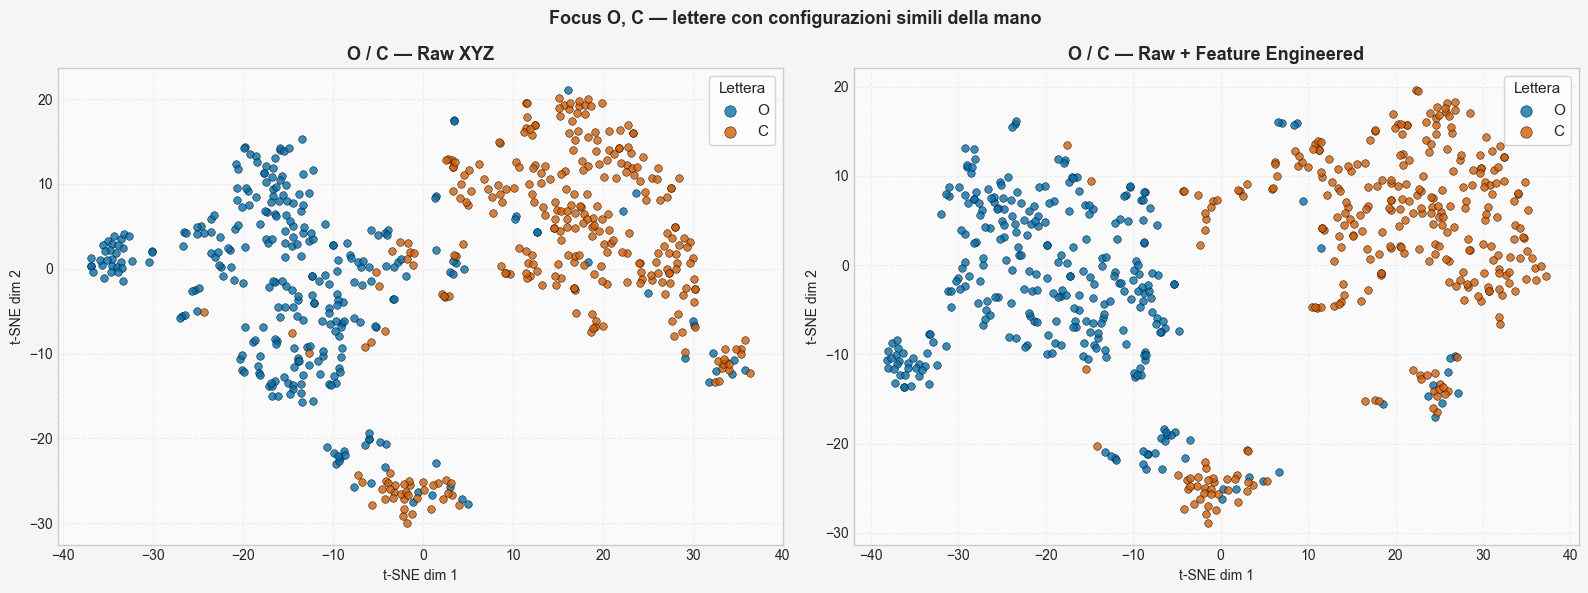

Salvato: 06_tsne_OC.png


In [38]:
import matplotlib.pyplot as plt

palette_oc = {
    'O': '#0072B2',  # blu
    'C': '#D55E00'   # arancione/vermiglio
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sfondo figura
fig.patch.set_facecolor('#F5F5F5')

for ax, emb, title in zip(
        axes,
        [emb_oc_raw, emb_oc_all],
        ['Raw XYZ', 'Raw + Feature Engineered']):

    ax.set_facecolor('#FAFAFA')
    ax.grid(True, linestyle='--', alpha=0.25)

    for lbl in FOCUS_OC:
        mask = (lab_oc == lbl)

        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            c=palette_oc[lbl],
            label=lbl,
            s=30,
            alpha=0.8,
            edgecolors='black',
            linewidths=0.4
        )

    ax.set_title(f'O / C — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')

    ax.legend(
        title='Lettera',
        fontsize=11,
        title_fontsize=11,
        markerscale=1.5,
        frameon=True
    )

plt.suptitle(
    'Focus O, C — lettere con configurazioni simili della mano',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '06_tsne_OC.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

print('Salvato: 06_tsne_OC.png')